# Вакцинация восприимчивых
Дополнительное задание 6: доля текущих S переводится в R в день 0 или 10.
Эффективность вакцины принята равной 100%; 0.5 означает половину S,
а не половину всей популяции. Доли 0,0.25,0.5,0.6,0.75; десять повторов.

In [1]:
using DrWatson
@quickactivate "project"
using project.SIRDES
using CSV, DataFrames, Statistics, StatsPlots
include(srcdir("experiments.jl"))
using .Experiments

In [2]:
rows=NamedTuple[]
fig=plot(;xlabel="Time",ylabel="I",title="Vaccination at day 0, seed=5001",size=(1000,550))
for time in [0.0,10.0], fraction in [0.0,.25,.5,.6,.75], rep in 1:10
    model,result=simulate(family="vaccination",seed=5000+rep,
        vaccine_time=time,vaccine_fraction=fraction)
    push!(rows,result)
    time==0 && rep==1 && plot!(fig,model.ta,model.Ia;label="fraction=$(fraction)",lw=2)
end
runs=save_table("vaccination-runs",DataFrame(rows));

## Измерение предотвращённых инфекций
ever_infected=I₀+новые инфекции; вакцинированные сюда не входят.
R(T) смешивает выздоровевших и вакцинированных и не является заболеваемостью.

Row,vaccine_time,vaccine_fraction,peak_mean,infected_mean,I_T_mean
,Float64,Float64,Float64,Float64,Float64
1,0.0,0.0,173.2,787.2,25.9
2,0.0,0.25,73.9,414.1,29.6
3,0.0,0.5,18.2,78.8,3.4
4,0.0,0.6,12.3,35.4,0.9
5,0.0,0.75,11.1,16.6,0.0
6,10.0,0.0,173.2,787.2,25.9
7,10.0,0.25,104.0,497.8,19.8
8,10.0,0.5,79.2,296.8,6.0
9,10.0,0.6,76.1,248.3,2.7


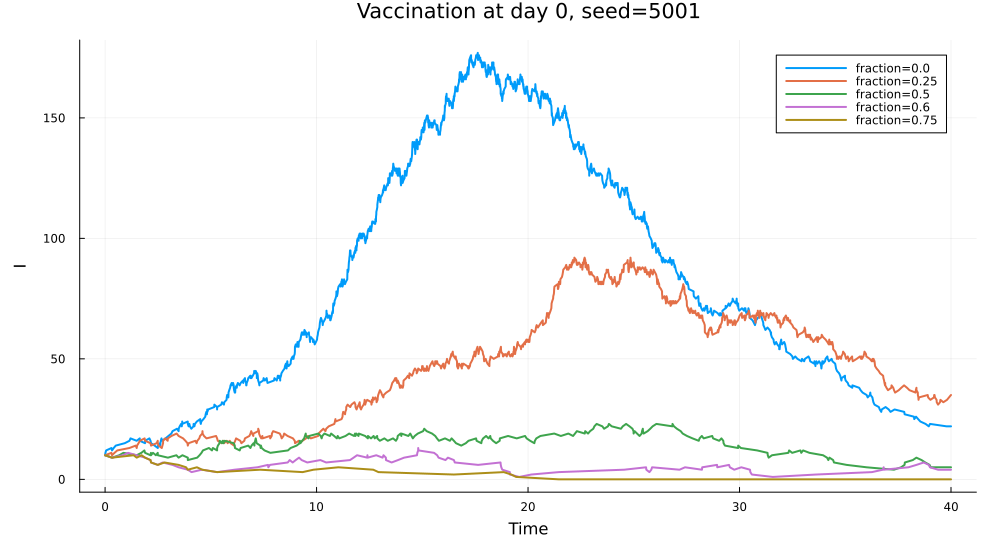

In [3]:
summary=save_table("vaccination-summary",summarize(runs,[:vaccine_time,:vaccine_fraction]))
display(select(summary,:vaccine_time,:vaccine_fraction,:peak_mean,:infected_mean,:I_T_mean))
savefig(fig,figure_path("10-plot"))
display(fig)

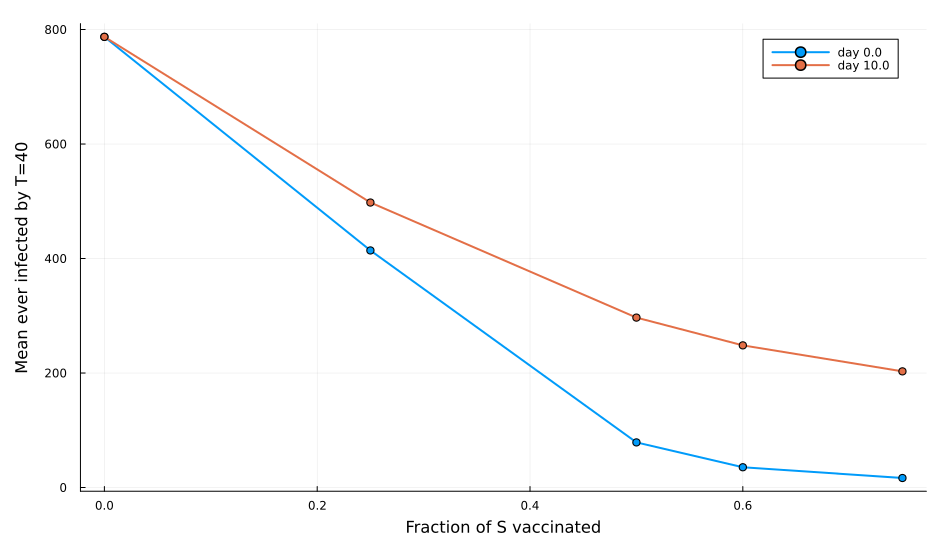

In [4]:
fig2=plot(;xlabel="Fraction of S vaccinated",ylabel="Mean ever infected by T=40",size=(950,550))
for time in [0.0,10.0]
    part=sort(filter(r->r.vaccine_time==time,summary),:vaccine_fraction)
    plot!(fig2,part.vaccine_fraction,part.infected_mean;marker=:circle,label="day $(time)",lw=2)
end
savefig(fig2,figure_path("11-plot"))
display(fig2)

## Порог среднего поля
R_eff=βc S/(γ(N−1)); ранняя вакцинация достаточной доли снижает его ниже 1.
Это критерий среднего поля, а не гарантия отсутствия вторичных случаев.

In [5]:
critical_fraction=1-BASE_P[3]*(sum(BASE_U)-1)/(BASE_P[1]*BASE_P[2]*BASE_U[1])
display((critical_fraction=critical_fraction,))

(critical_fraction = 0.4954545454545455,)